In [12]:
"""
Image QC — standalone script
=============================
Walks ROOT_DIR/[PROTEIN]/[ISOFORM]/ folder tree, computes per-image QC metrics,
reports isoform-level statistics, and copies passing images to a mirrored folder tree.

The subfolder name is used directly as the isoform name — no suffix list required.
This handles both experimental proteins (e.g. PROT1/PROT1-L/, PROT1/PROT1-S/) and
controls (e.g. control/EGFP-NLS/, control/ATXN1/) with the same code.

Usage:
    Edit ROOT_DIR / PASS_DIR below, then:
        python qc.py

    Or pass the root folder as a CLI argument:
        python qc.py /path/to/images

Folder structure expected:
    ROOT_DIR/
        PROTEIN/
            ISOFORM-A/
                img1.tiff
            ISOFORM-B/
                img1.tiff
        control/
            EGFP-NLS/
                img1.tiff
            ATXN1/
                img1.tiff

QC metrics per image:
    mean_intensity_fg  — mean raw pixel value within the foreground mask (uint16)
    foreground_frac    — fraction of image pixels above Triangle threshold
    focus_score        — normalised Laplacian variance (sharpness proxy)
    saturation_frac    — fraction of pixels at the uint16 maximum value

Outputs (written to OUT_DIR, default = ROOT_DIR):
    qc_report.csv          one row per image: metrics + protein + isoform + PASS/FAIL
    qc_isoform_summary.csv one row per isoform: pass rate + mean metrics
    fig_qc_summary.png     overall metric distributions + fail-reason pie
    fig_qc_isoform.png     per-isoform pass rate + metric boxplots

Passing images are copied to:
    PASS_DIR/
        PROTEIN/
            ISOFORM-A/
                img1.tiff   ← only QC-passing images

Install:
    pip install tifffile numpy scikit-image matplotlib pandas imagecodecs
"""

import os, sys, glob, shutil
import tifffile
import numpy as np
from skimage import filters, morphology
from skimage.filters import laplace
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [13]:

# ── USER SETTINGS ──────────────────────────────────────────────────────────────
QC_ROOT_DIR         = './images'            # root image folder; overridden by CLI arg
QC_IMG_EXT          = '*.tif*'
QC_OUT_DIR          = './outputs'                    # for CSVs/figures; defaults to ROOT_DIR
QC_PASS_DIR         = './images_qc_pass'   # destination for passing images

In [14]:
# ── QC THRESHOLDS ──────────────────────────────────────────────────────────────
QC_MIN_MEAN_INTENSITY_FG = 500
QC_MAX_MEAN_INTENSITY_FG = 60000
QC_MIN_FOREGROUND_FRAC   = 0.025
QC_MAX_FOREGROUND_FRAC   = 0.85
QC_MIN_FOCUS_SCORE       = 0.01
QC_MAX_SATURATION_FRAC   = 0.01


In [15]:
# ── QC helper functions ────────────────────────────────────────────────────────
QC_METRIC_COLS = ['mean_intensity_fg', 'foreground_frac', 'focus_score', 'saturation_frac']

def qc_compute_metrics(img_raw):
    h, w       = img_raw.shape[:2]
    n_px       = h * w
    uint16_max = (np.iinfo(np.uint16).max if img_raw.dtype == np.uint16
                  else int(img_raw.max()))
    m = {}
    m['saturation_frac'] = float((img_raw >= uint16_max).sum() / n_px)
    img_norm = img_raw.astype(np.float32) / max(float(img_raw.max()), 1.0)
    t    = filters.threshold_triangle(img_norm)
    mask = morphology.remove_small_objects(img_norm > t, min_size=50)
    m['foreground_frac']   = float(mask.sum() / n_px)
    m['mean_intensity_fg'] = float(img_raw[mask].mean()) if mask.sum() > 0 else 0.0
    lap = laplace(img_norm)
    m['focus_score'] = float(lap.var() / (img_norm.var() + 1e-9))
    return m

def qc_apply_thresholds(m):
    reasons = []
    if m['mean_intensity_fg'] < QC_MIN_MEAN_INTENSITY_FG:
        reasons.append(f"dim fg ({m['mean_intensity_fg']:.0f}<{QC_MIN_MEAN_INTENSITY_FG})")
    if m['mean_intensity_fg'] > QC_MAX_MEAN_INTENSITY_FG:
        reasons.append(f"saturated fg ({m['mean_intensity_fg']:.0f}>{QC_MAX_MEAN_INTENSITY_FG})")
    if m['saturation_frac'] > QC_MAX_SATURATION_FRAC:
        reasons.append(f"pixel sat ({m['saturation_frac']*100:.2f}%)")
    if m['foreground_frac'] < QC_MIN_FOREGROUND_FRAC:
        reasons.append(f"sparse fg ({m['foreground_frac']*100:.1f}%)")
    if m['foreground_frac'] > QC_MAX_FOREGROUND_FRAC:
        reasons.append(f"over-confluent ({m['foreground_frac']*100:.1f}%)")
    if m['focus_score'] < QC_MIN_FOCUS_SCORE:
        reasons.append(f"out of focus ({m['focus_score']:.4f})")
    return len(reasons) == 0, reasons

print('QC helpers defined')

QC helpers defined


In [16]:
# ── Run QC ────────────────────────────────────────────────────────────────────
protein_dirs = sorted([d for d in glob.glob(os.path.join(QC_ROOT_DIR, '*')) if os.path.isdir(d)])
print(f'Found {len(protein_dirs)} protein folder(s) in {QC_ROOT_DIR}\n')

qc_records = []
for pdir in protein_dirs:
    protein = os.path.basename(pdir)
    isoform_dirs = sorted([d for d in glob.glob(os.path.join(pdir, '*')) if os.path.isdir(d)])
    if not isoform_dirs:
        print(f'  WARNING: no isoform subfolders in {pdir}')
        continue
    for idir in isoform_dirs:
        isoform = os.path.basename(idir)
        paths   = sorted(glob.glob(os.path.join(idir, QC_IMG_EXT)))
        if not paths:
            continue
        print(f'  {protein}/{isoform}  ({len(paths)} images)')
        for p in paths:
            fname = os.path.basename(p)
            try:
                img = tifffile.imread(p)
                if img.ndim > 2: img = img[..., 0]
            except Exception as e:
                qc_records.append({'file': fname, 'path': p, 'protein': protein,
                                   'isoform': isoform, 'qc_pass': False,
                                   'qc_fail_reason': f'read error: {e}',
                                   **{c: np.nan for c in QC_METRIC_COLS}})
                continue
            m, (passed, reasons) = qc_compute_metrics(img), qc_apply_thresholds(qc_compute_metrics(img))
            m = qc_compute_metrics(img)
            passed, reasons = qc_apply_thresholds(m)
            qc_records.append({'file': fname, 'path': p, 'protein': protein,
                               'isoform': isoform, 'qc_pass': passed,
                               'qc_fail_reason': '; '.join(reasons),
                               **m})
df_qc = pd.DataFrame(qc_records)
n_total = len(df_qc); n_pass = df_qc['qc_pass'].sum(); n_fail = n_total - n_pass
print(f'\nTotal: {n_total}  |  Pass: {n_pass}  |  Fail: {n_fail}  ({100*n_pass/max(n_total,1):.1f}% pass)')

Found 102 protein folder(s) in ./images

  ABI1/ABI1-L  (72 images)
  ABI1/ABI1-S  (72 images)
  ABI2/ABI2-L  (192 images)
  ABI2/ABI2-S  (192 images)
  ABLIM3/ABLIM3-L  (405 images)
  ABLIM3/ABLIM3-S  (341 images)
  AFTPH/AFTPH-L  (177 images)
  AFTPH/AFTPH-S  (177 images)
  AGAP1/AGAP1-L  (228 images)
  AGAP1/AGAP1-S  (228 images)
  AGAP2/AGAP2-L  (328 images)
  AGAP2/AGAP2-S  (328 images)
  ANXA7/ANXA7-L  (228 images)
  ANXA7/ANXA7-S  (228 images)
  AP1B1/AP1B1-L  (228 images)
  AP1B1/AP1B1-S  (228 images)
  AP1B1/AP1B1-S1  (100 images)
  AP1B1/AP1B1-S2  (100 images)
  AP1S2/AP1S2-L  (228 images)
  AP1S2/AP1S2-S  (228 images)
  AP2A1/AP2A1-L  (305 images)
  AP2A1/AP2A1-S  (305 images)
  APBA2/APBA2-L  (326 images)
  APBA2/APBA2-S  (326 images)
  APBB2/APBB2-L  (226 images)
  APBB2/APBB2-S  (226 images)
  APBB3/APBB3-L  (405 images)
  APBB3/APBB3-S  (405 images)
  ASAP1/ASAP1-L  (292 images)
  ASAP1/ASAP1-S  (373 images)
  ASPH/ASPH-L  (245 images)
  ASPH/ASPH-S  (245 images)
  ATG13

In [18]:
# ── Isoform summary table ──────────────────────────────────────────────────────
iso_rows = []
for iso in sorted(df_qc['isoform'].unique()):
    sub = df_qc[df_qc['isoform'] == iso]
    n_i, n_p = len(sub), int(sub['qc_pass'].sum())
    row = {'isoform': iso, 'protein': sub['protein'].iloc[0],
           'n_total': n_i, 'n_pass': n_p, 'n_fail': n_i - n_p,
           'pass_rate': n_p / max(n_i, 1)}
    for col in QC_METRIC_COLS:
        row[f'mean_{col}'] = sub[col].mean()
    iso_rows.append(row)
df_qc_iso = pd.DataFrame(iso_rows)
display(df_qc_iso)

,isoform,protein,n_total,n_pass,n_fail,pass_rate,mean_mean_intensity_fg,mean_foreground_frac,mean_focus_score,mean_saturation_frac
0,ABI1-L,ABI1,72,8,64,0.111111,2095.655891,0.014083,0.507708,0.000000e+00
1,ABI1-S,ABI1,72,14,58,0.194444,906.455666,0.011955,4.220887,0.000000e+00
2,ABI2-L,ABI2,192,131,61,0.682292,2925.389552,0.036374,0.164612,0.000000e+00
3,ABI2-S,ABI2,192,127,65,0.661458,2943.996604,0.046781,1.241761,1.035951e-06
4,ABLIM3-L,ABLIM3,405,119,286,0.293827,2233.139443,0.020699,3.141444,7.620790e-08
...,...,...,...,...,...,...,...,...,...,...
210,VAV3-L,VAV3,245,67,178,0.273469,883.774672,0.018869,3.277273,2.099605e-08
211,VAV3-S,VAV3,245,77,168,0.314286,1237.534555,0.031494,1.945704,1.399737e-08
212,ZFYVE27-L,ZFYVE27,409,128,281,0.312958,2314.719282,0.036435,5.473792,0.000000e+00
213,ZFYVE27-S,ZFYVE27,490,230,260,0.469388,1785.258079,0.035798,3.112054,0.000000e+00


In [19]:
# ── Copy passing images ────────────────────────────────────────────────────────
n_copied = 0
for _, row in df_qc[df_qc['qc_pass']].iterrows():
    dst = os.path.join(QC_PASS_DIR, row['protein'], row['isoform'], row['file'])
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    shutil.copy2(row['path'], dst)
    n_copied += 1
print(f'Copied {n_copied} passing images to {QC_PASS_DIR}/')

# Save CSVs
os.makedirs(QC_OUT_DIR, exist_ok=True)
df_qc.to_csv(os.path.join(QC_OUT_DIR, 'qc_report.csv'), index=False)
df_qc_iso.to_csv(os.path.join(QC_OUT_DIR, 'qc_isoform_summary.csv'), index=False)
print('Saved qc_report.csv and qc_isoform_summary.csv')

Copied 26694 passing images to ./images_qc_pass/
Saved qc_report.csv and qc_isoform_summary.csv


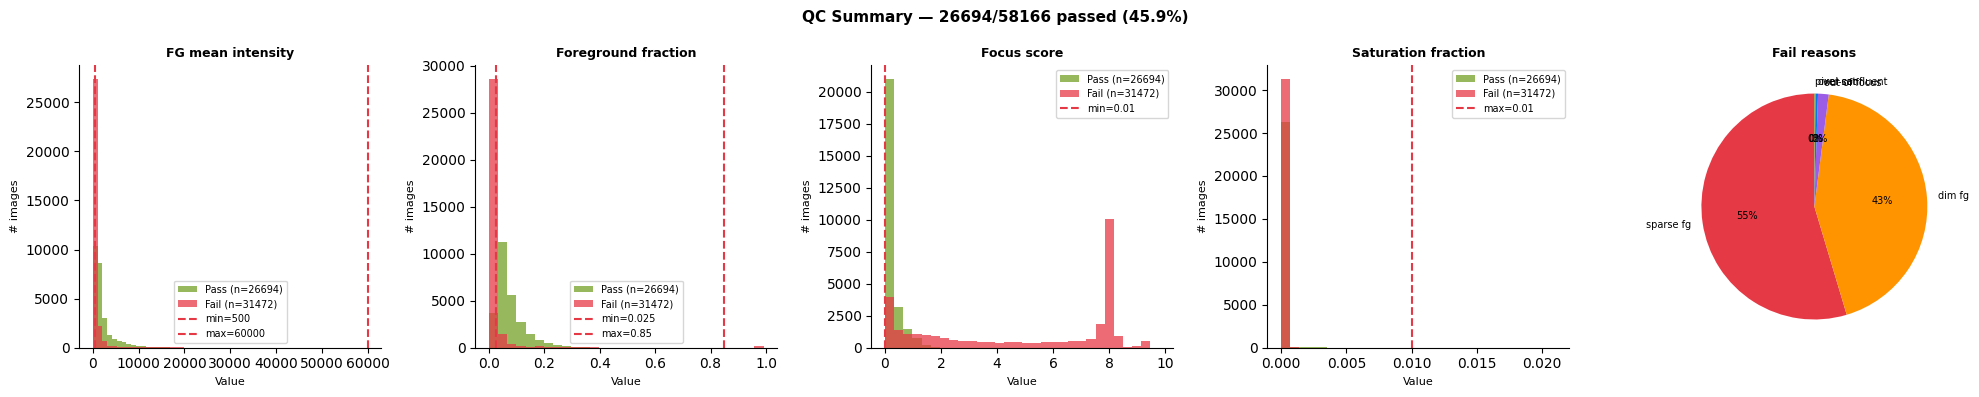

In [20]:
# ── QC figures ─────────────────────────────────────────────────────────────────
metric_labels = {'mean_intensity_fg': 'FG mean intensity',
                 'foreground_frac': 'Foreground fraction',
                 'focus_score': 'Focus score',
                 'saturation_frac': 'Saturation fraction'}
thresh_lines  = {'mean_intensity_fg': [(QC_MIN_MEAN_INTENSITY_FG,'min'),(QC_MAX_MEAN_INTENSITY_FG,'max')],
                 'foreground_frac':   [(QC_MIN_FOREGROUND_FRAC,'min'),(QC_MAX_FOREGROUND_FRAC,'max')],
                 'focus_score':       [(QC_MIN_FOCUS_SCORE,'min')],
                 'saturation_frac':   [(QC_MAX_SATURATION_FRAC,'max')]}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for j, col in enumerate(QC_METRIC_COLS):
    ax = axes[j]
    pv = df_qc[df_qc['qc_pass']][col].dropna()
    fv = df_qc[~df_qc['qc_pass']][col].dropna()
    av = df_qc[col].dropna()
    bins = np.linspace(av.min(), av.max(), 31) if len(av) > 1 else 30
    if len(pv): ax.hist(pv, bins=bins, color='#75A025', alpha=0.75, label=f'Pass (n={len(pv)})')
    if len(fv): ax.hist(fv, bins=bins, color='#E63946', alpha=0.75, label=f'Fail (n={len(fv)})')
    for t, k in thresh_lines.get(col, []):
        ax.axvline(t, color='#E63946', lw=1.5, ls='--', label=f'{k}={t}')
    ax.set_title(metric_labels[col], fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8); ax.set_ylabel('# images', fontsize=8)
    ax.legend(fontsize=7); ax.spines[['top','right']].set_visible(False)

ax = axes[4]
if n_fail > 0:
    rf = []
    for r in df_qc[~df_qc['qc_pass']]['qc_fail_reason']:
        rf.extend([x.split('(')[0].strip() for x in r.split(';') if x.strip()])
    rc = pd.Series(rf).value_counts()
    ax.pie(rc.values, labels=[r[:28] for r in rc.index], autopct='%1.0f%%', startangle=90,
           colors=['#E63946','#FF9400','#9B5DE5','#0279EE','#75A025'], textprops={'fontsize':7})
    ax.set_title('Fail reasons', fontsize=9, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'All passed', ha='center', va='center', fontsize=11, color='#75A025')
    ax.axis('off')

fig.suptitle(f'QC Summary — {n_pass}/{n_total} passed ({100*n_pass/max(n_total,1):.1f}%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(QC_OUT_DIR, 'fig_qc_summary.png'), dpi=150, bbox_inches='tight')
plt.show()